In [1]:
import spot
from spot.jupyter import display_inline
spot.setup()

Work in progress for a representation of ω-automata (a.k.a. `twa` in Spot) using MTBDDs.  We initially implemented a transition-based variant, before realizing that using MTBDDs, the transition-based and state-based version of an automaton have exactly the same structure, the state-based version is even slightly more memory efficient.

So even if the transition-based variant still exist, its state-based counterpart is more developed.

# Transition-based variant (mtdtwa)

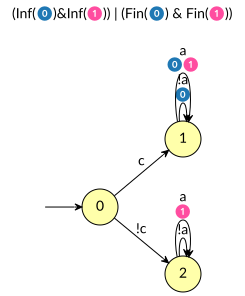

In [2]:
a = spot.translate("GFa <-> c", "generic", "deterministic")
a

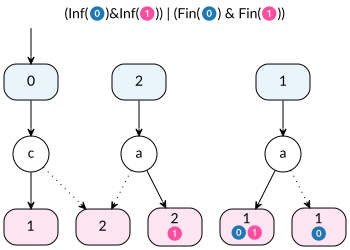

In [3]:
m = spot.dtwa_to_mtdtwa(a)
m

Each terminal stores an integer that allows to retrieve the data presented in the leaves above: a set of colors, and a destination state.

In [4]:
for i, d in enumerate(m.terminal_data_map):
    print(f"terminal_data_map[{i}] = {d}")

terminal_data_map[0] = (spot.mark_t([]), 1)
terminal_data_map[1] = (spot.mark_t([]), 2)
terminal_data_map[2] = (spot.mark_t([0]), 1)
terminal_data_map[3] = (spot.mark_t([0, 1]), 1)
terminal_data_map[4] = (spot.mark_t([1]), 2)


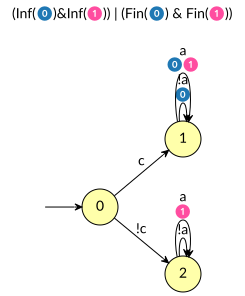

In [5]:
m.as_twa()

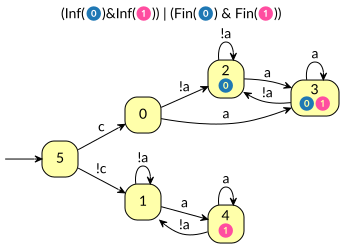

In [6]:
m.as_twa(True)

# State-based variant (mtdswa)

This version is closer Mona's DFA representation.  An `mtdswa` is just a pair of array indexed by state numbers.  The value of `states[i]` is an MTBDD encoding the successors states of state `i`, with terminal containing state indices.  The value of `colors[i]` gives the set of colors associated to state `i`.  The set of MTBDD nodes needed to represent a `mtdswa` is not bigger than the one used to represent an `mtdtwa` as states that have different colors but behave the same will share their MTBDD.   This representation seems much easier to work with.

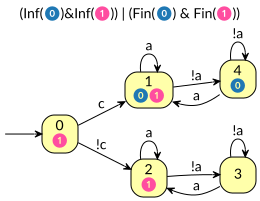

In [7]:
a2 = spot.sbacc(a)
a2

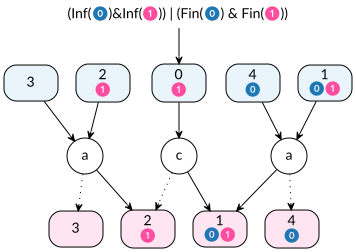

In [8]:
m2 = spot.dtwa_to_mtdswa(a2)
display(m2)

In [9]:
for i, d in enumerate(m2.colors):
    print(f"colors[{i}] = {d}")

colors[0] = {1}
colors[1] = {0,1}
colors[2] = {1}
colors[3] = {}
colors[4] = {0}


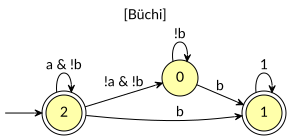

In [10]:
a3 = spot.translate("Ga | Fb")
a3

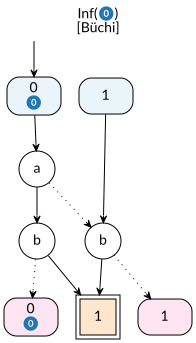

In [11]:
m3 = spot.dtwa_to_mtdswa(a3)
m3

In [12]:
display_inline(m3.as_twa(), m3.as_twa(True))

In [13]:
display_inline(m2.as_twa(), m2.as_twa(True))

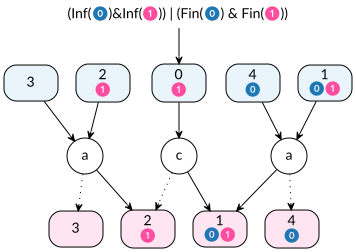

In [14]:
m2

# SCC computations

The `scc_vector` assigne each state to the index of a maximal SCC ordered topologically (each SCC can only reach SCC with smaller indices).

The computation is performed in Linear time by considering the mtdswa as an oriented graph.  Passing option 's' to `show()` will highlight non-trivial SCCs (including their states and MTBDD nodes).

In [15]:
spot.scc_vector(m2)

(2, 1, 0, 0, 1)

In [16]:
spot.scc_vector(m3)

(1, 0)

In [17]:
m2.show("s")

In [18]:
m3.show("s")

In [19]:
a = spot.translate("(a U b) | XG(c)", "det")
m4 = spot.dtwa_to_mtdswa(a)
print(spot.scc_vector(m4))
m4.show('s')

(3, 1, 0, 2)


In [20]:
a = spot.translate("(a U b) & GFa & GFb & FGc", "det", "sbacc", "gen")
m5 = spot.dtwa_to_mtdswa(a)
m5.show('s')

**TODO**: The linking above is not optimal.  Since all states 1,2,3,4,5 recognize the same language, it would be better to always jump on the same sate when entering this SCC.  That way the two transient "b" node above false could be merged.  Currently we don't care too much because those nodes were converted from an explicit representation.  However when we start building translating LTL to mtdswa directly, we can probably do better.

The `false` and `true` automata don't display very well because they have to introduce a state that points to the constant.  But that should be interpreted as a single SCC.  (Technically, the blue nodes at the top of the figures do not really belong to the SCCs.)

In [21]:
a = spot.translate("true", "det")
m5 = spot.dtwa_to_mtdswa(a)
print(spot.scc_vector(m5))
m5.show('s')

(0,)


# Translation from obligation formula to Deterministic Weak BA 

... represented as MTDSWA.

The translation rules are even simpler than those of for translating LTLf to MTDFA (see the [CIAA'25 paper](https://www.lrde.epita.fr/~adl/dl/adl/duret.25.ciaa.pdf) or the [ltlf2dfa notebook](https://spot.lre.epita.fr/ipynb/ltlf2dfa.html)).   

Let us use $\boxed{\varphi}$ to denote a terminal labeled by LTL formula $\varphi$.  Let us further assume that applying any Boolean operator $\odot\in\{\land,\lor,\leftarrow,\leftrightarrow,\oplus,...\}$ between two terminals results in a terminal labeled by the result of applying $\odot$ on the two labels, i.e., $\boxed{\alpha}\odot\boxed{\beta}=\boxed{\alpha\odot\beta}$.  Using that convention, the standard apply2() operation of BDD can be extended to support Boolean operation on MTBDD labeled by LTL formulas.

Then the translation of an LTL formula to MTBDD with LTL terminals following the standard expansion rules of LTL:

\begin{align}
   \mathit{tr}(b) &= \text{BDD representation of $b$}& \text{for any Boolean formula $b$} \\
   \mathit{tr}(\mathop{\mathsf{X}}\varphi) &= \boxed{\varphi} \\
   \mathit{tr}(\lnot\varphi) &= \lnot\mathit{tr}(\varphi) \\
   \mathit{tr}(\alpha \odot \beta) &= \mathit{tr}(\alpha)\odot \mathit{tr}(\beta) & \text{for any Boolean operator $\odot\in\{\land,\lor,\leftarrow,\leftrightarrow,\oplus,...\}$}\\
   \mathit{tr}(\alpha \mathbin{\mathsf{U}} \beta) &= \mathit{tr}(\beta)\lor(\mathit{tr}(\alpha)\land\boxed{\alpha \mathbin{\mathsf{U}} \beta}) \\
   \mathit{tr}(\alpha \mathbin{\mathsf{W}} \beta) &= \mathit{tr}(\beta)\lor(\mathit{tr}(\alpha)\land\boxed{\alpha \mathbin{\mathsf{W}} \beta}) \\
   \mathit{tr}(\alpha \mathbin{\mathsf{M}} \beta) &= \mathit{tr}(\beta)\land(\mathit{tr}(\alpha)\lor\boxed{\alpha \mathbin{\mathsf{M}} \beta}) \\
   \mathit{tr}(\alpha \mathbin{\mathsf{R}} \beta) &= \mathit{tr}(\beta)\land(\mathit{tr}(\alpha)\lor\boxed{\alpha \mathbin{\mathsf{R}} \beta}) \\
   \mathit{tr}(\mathop{\mathsf{F}} \varphi) &= \mathit{tr}(\varphi)\lor\boxed{\mathop{\mathsf{F}}\varphi} \\
   \mathit{tr}(\mathop{\mathsf{G}} \varphi) &= \mathit{tr}(\varphi)\land\boxed{\mathop{\mathsf{G}}\varphi} \\
\end{align}

The above rules for $\mathit{tr}(\varphi)$ can be used to obtain the MTBDD representing the outgoing edges of a state $\varphi$.   By iterating this for all formulas that label terminals reachable from $\varphi$, we can build the structure of the automaton for $\varphi$.  

What remains is to decide for each state whether it is accepting.  The $\lambda$ function below does that by just checking the top-level temporal operators.  When know that states labeled by strong operators ($\mathsf{F}$, $\mathsf{U}$, $\mathsf{M}$) should not be accepting, and states labeled by weak operators ($\mathsf{G}$, $\mathsf{W}$, $\mathsf{R}$) should be accepting.  Combinations of those follow the semantics of the Boolean operators.

\begin{align}
    \lambda(\top)&=\top\\
    \lambda(\bot)&=\bot\\
    \lambda(a) &= * & \text{for any atomic proposition}\\
    \lambda(\lnot\varphi) &= \lnot\lambda(\varphi)\\
    \lambda(\mathop{\mathsf{X}}\varphi) &= \lambda(\varphi) \\
    \lambda(\alpha \odot \beta) &= \lambda(\alpha)\odot\lambda(\beta) & \text{for any Boolean operator $\odot\in\{\land,\lor,\leftarrow,\leftrightarrow,\oplus,...\}$} \\
    \lambda(\alpha \mathbin{\mathsf{U}} \beta) &= \bot \\
    \lambda(\alpha \mathbin{\mathsf{M}} \beta) &= \bot \\
    \lambda(\mathop{\mathsf{F}}\varphi) &= \bot \\
    \lambda(\alpha \mathbin{\mathsf{W}} \beta) &= \top \\
    \lambda(\alpha \mathbin{\mathsf{R}} \beta) &= \top \\
    \lambda(\mathop{\mathsf{G}}\varphi) &= \top \\
\end{align}

Here the value $*$ should be interpreted as a joker that can simply be ignored when being combined with other Boolean operations:
\begin{align}
  \top\land * &= \top   & \bot \land * &= \bot  & * \land * &= * \\ 
  \top\lor *  &= \top   & \bot \land * &= \bot  & * \lor *  &= * \\
  \top\leftrightarrow * &= \top & \bot \leftrightarrow * &= \top & * \leftrightarrow * &= * \\
  \top\oplus * &= \top & \bot \oplus * &= \top & * \oplus * &= * \\
               &        &              &       &         \lnot * &= * 
\end{align}

By construction, one can see that the only formulas $\varphi$ for which $\lambda(\varphi)=*$ must be obtained by using only atomic propositions, Boolean operators and $\mathop{X}$ operators, this corresponds to formulas that are both safety and co-safety syntactically.  If such a formula labels a state, that state cannot be part of any cycle, i.e., it is a transient state, and its acceptance is irrelevant.  Hence the use of a joker.

For the construction, states labeled by a formula $\varphi$ such that $\lambda(\varphi)=\top$ should be tagged as accepting, states where $\lambda(\varphi)=\bot$ must be tagged as rejecting, and states for which $\lambda(\varphi)=*$ can be tagged either way without impact on the language.

In the implementation we do not actually use the above ternary logic.  Instead we have $\lambda(a)=\bot$, and the Boolean operators (which are n-ary in the case of $\land$ and $\lor$) are modified to ignore the arguments that are both safety and co-safety syntactically (Spot maintains this class membership as a property bit in each formula, so this can be tested in constant time).

In [22]:
t1 = spot.obligation_to_mtdswa('a W b U c')
t1.show('s')

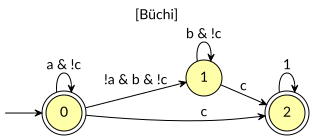

In [23]:
t1.as_twa(True)

In [24]:
t2 = spot.obligation_to_mtdswa('Fa & Fb & Fc')
t2.show('s')

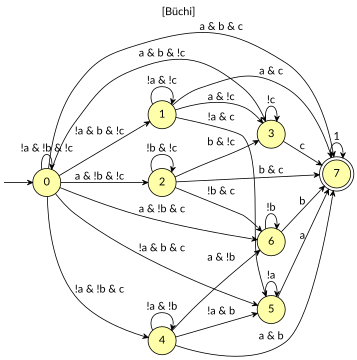

In [25]:
t2.as_twa(True)

In [26]:
t3 = spot.obligation_to_mtdswa('G(p1 <-> X!p1) | F(p0 & Xp1)')
t3.show('s')

In [27]:
t3.as_twa(True).show('.s')

Here is a list of obligation formulas to check that the new translation is equivalent to the old one.

In [28]:
obligations = ['Gp',
               'Fr -> (!p U r)',
               '(!r U (p & !r)) | G!r',
               'Fr -> ((!p & !r) U (r | ((p & !r) U (r | ((!p & !r) U (r | ((p & !r) U (r | (!p U r)))))))))',
               'Fr -> (p U r)',
               'G(q -> Gp)',
               'Fr -> (!p U (r | s))',
               'Fr -> ((p -> (!r U (!r & s))) U r)',
               'Fp -> (!p U (!p & s & X(!p U t)))',
               'Fr -> (!p U (r | (!p & s & X(!p U t))))',
               'F(s & XFt) -> (!s U p)',
               'Fr -> (!(!r & s & X(!r U (!r & t))) U (p | r))',
               'Fr -> ((p -> (!r U (!r & s & X(!r U t)))) U r)',
               'Fr -> ((p -> (!r U (!r & s & !z & X((!r & !z) U t)))) U r)',
               'Fp',
               'G!q | F(q & Fp)',
               '(!p U s) | Gp',
               'Fr -> (((s & X(!r U t)) -> X(!r U (t & Fp))) U r)',
               'G(p1 <-> X!p1) | F(p0 & Xp1)']
for obl in obligations:
    f = spot.formula(obl)
    t1 = spot.obligation_to_mtdswa(f).as_twa(True)    # non-minimized, via MTBDDs
    t2 = f.translate('deterministic')                 # minimized, via the historical and explicit construction 
    print(t1.num_states(), t2.num_states(), spot.are_equivalent(t1, t2), f)

1 1 True Gp
3 3 True (!p U r) | G!r
2 2 True p R !r
7 7 True G!r | ((!p & !r) U ((p & !r) U ((!p & !r) U ((p & !r) U (!p U r)))))
3 3 True (p U r) | G!r
2 2 True G(!q | Gp)
3 3 True (!p U (r | s)) | G!r
3 3 True G!r | ((!p | (s M !r)) U r)
3 3 True (s & X(!p U t)) R !p
4 4 True (!p U (r | (!p & s & X(!p U t)))) | G!r
3 3 True (!s U p) | G(!s | XG!t)
5 4 True G!r | ((!s | X(!t W r)) U (p | r))
4 4 True G!r | ((!p | ((s & X(!r U t)) M !r)) U r)
4 4 True G!r | ((!p | ((s & !z & X((!r & !z) U t)) M !r)) U r)
2 2 True Fp
3 3 True !q W (q & Fp)
4 4 True (!p U s) | Gp
6 6 True G!r | ((!s | X((!r U (t & Fp)) | (r R !t))) U r)
7 7 True F(p0 & Xp1) | G((p1 & X!p1) | (!p1 & Xp1))


Let's look at the only case where the new translation produces one extra state compared to the reference implementation (which is already minimized).

In [29]:
f = spot.formula('G!r | ((!s | X(!t W r)) U (p | r))')

In [30]:
a = spot.obligation_to_mtdswa(f)
a.show('s')

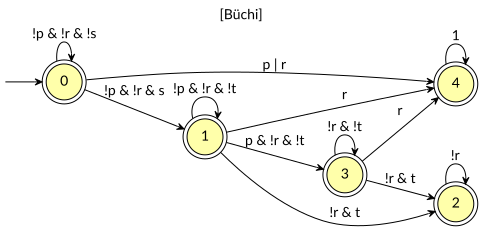

In [31]:
b1 = a.as_twa(True)
b1

State 1 and 3 can be merged.  Here is the minimized output from the historical translation:

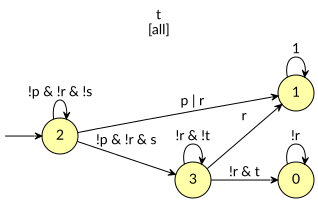

In [32]:
b2 = f.translate('deterministic')
b2

In [33]:
spot.are_equivalent(b1, b2)

True

# Moore's Minimization

Moore's DFA minimization algorithm is easy to implement on MTBDD-based ω-automata, just using the color of the states for the initial partition.  However, despite its name, it does not guarantee a minimal automaton when applied to ω-automata.  (There is a way to fix that for weak deterministic ω-automata, as we will see later.)  Moore's minimization algorirthm is quadratic (unlike Hopcroft's which does it in $O(n \log n)$), but it is very suited to MTBDD-based representation because to perform one iteration of the algorithm, we just have to replace each terminal by its current class number, and after rewriting the MTBDDs states the new partition can be read by looking which state have the same MTBDD representation.

The minimization currently forces the `bddtrue` and `bddfalse` terminals in separate classes.  So, for instance, if you build a MTDSWA that contains a `bddtrue` terminal, and another accepting state that loops over itself with label "true", these two states won't be merged.   The minimization for `mtdfa` used to deal with this case, but that made the code more complex and harder to maintain.  In practice, the `bddtrue` and `bddfalse` terminals are only useful during the recursive translation, where they help shortcut BDD operations, but they are more annoying to deal with afterwards.  Hence this implementation of the minimization does not make any effort regarding those.

In a few sections will show how to change between constant-based (`bddtrue`, `bddfalse`), or state-based representations of sinks.  Therefore, fore precise minimization, one should call `a.sinks_as_states()` before `spot.minimize_mtdswa(a)`.

In the meantime, we can still use this algorithm to merge the two equivalent states in automaton `a`:

'before:'

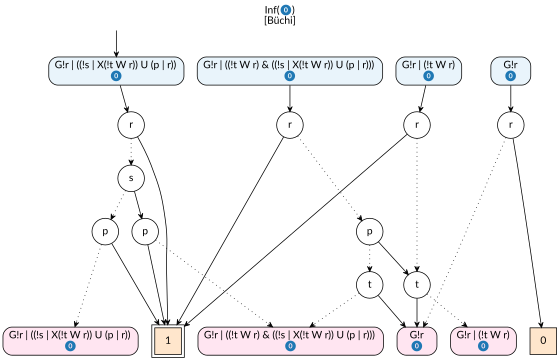

'after:'

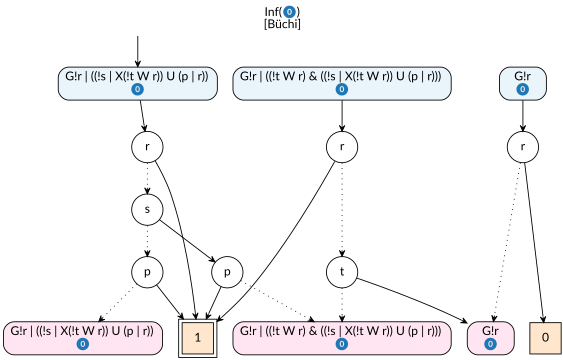

In [34]:
am = spot.minimize_mtdswa(a)
display("before:", a, "after:", am)

In [35]:
spot.are_equivalent(a.as_twa(), am.as_twa())

True

# Löding's preprocessing for weak DBAs

Let's look at a simple example to understand the problem why DFA minimization does not work immediately on weak deterministic ω-automata.

In [36]:
t4 = spot.obligation_to_mtdswa('a | Ga | F(b & Xa)')
t4.show('s')

On this example, we can see that the initial state is labeled by `a | Ga | F(b & Xa)`.  Because this disjunction contains the safety formula `Ga`, the state is marked as accepting.  However this formula is equivalent to `a | F(b & Xa)`, which is would be rejecting.  The different acceptance for those two states is not a threat to the validity of the translation: when the formula `a | Ga | F(b & Xa)` is translated into MTBDD, the superfluous `Ga` naturally disappear, so `a | Ga | F(b & Xa)` only occurs as a transient SCC, and its acceptance has no impact on the language of the automaton.  However the difference of acceptance prevent those two states from being merged by the DFA minimization algorithm.

In [37]:
spot.minimize_mtdswa(t4).show('s')

An easy fix here would be to detect that `a | Ga | F(b & Xa)` and `a | F(b & Xa)` have the same MTBDD encoding, and because `a | Ga | F(b & Xa)` is a transient state, decide to replace it by the other state.

[Löding's preprocessing](https://doi.org/10.1016/S0020-0190(00)00183-6) is a more general solution that decides for each transient state of a weak deterministic ω-automata whether it should be accepting or rejecting, in such a way that applying DFA minimization on the preprocessed ω-automata will ensure minimallity of the result.  Spot implements a variant of this preprocessing that assign to each SCC a rank such that:
- SCCs are accepting iff they have odd rank
- ranks can only decrease along a run of the automaton
- `bddfalse` and `bddtrue` implicitely have rank 0 and 1
- the rank assigned to each SCC is the minimal one that could be assigned given the above constraint.

The way to compute those ranks is quite straight forward and can be done in linear time: compute an SCC decomposition, then process it in a bottom-up way, assigning 0 or 1 to the bottommost depending on its acceptance. Moving up, the rank of a transient state is the maximum of the rank of its successors.  If an SCC is not transient, that computed maximum may have to be incremented by one to match the acceptance of the current SCC.

Even if the rank is SCC-based, the return value of `loding_weak_ranking` is an array giving the rank of each state.

In [38]:
spot.loding_weak_ranking(t4)

(2, 2, 2)

In this case all states have rank 2, so they should be rejecting.  `bddtrue` has rank 1 implicitely, but this is not indicated in the return.

We can also ask `loding_weak_ranking` to fix the acceptance of the transient states in the provided automaton:

In [39]:
spot.loding_weak_ranking(t4, True)

(2, 2, 2)

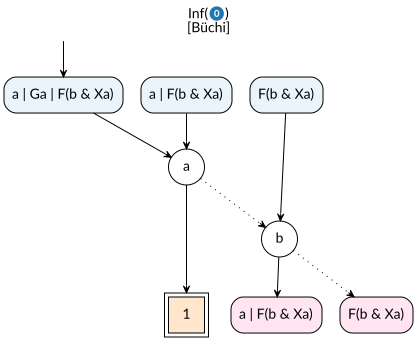

In [40]:
t4

And now we can minimize this like a DFA:

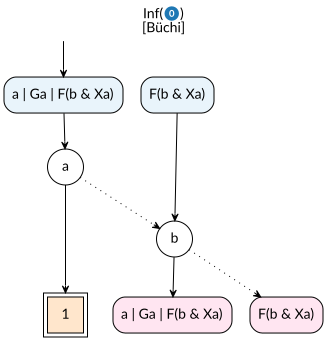

In [41]:
spot.minimize_mtdswa(t4)

Here is a larger example:

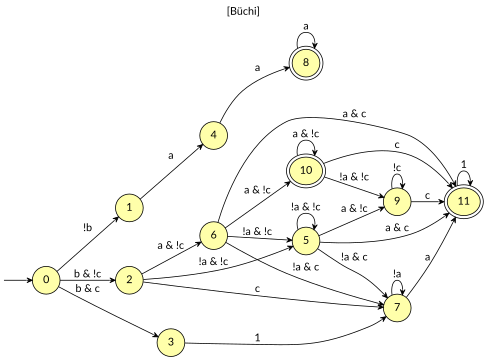

In [42]:
t5 = spot.obligation_to_mtdswa('XXFa & ((b & Fc) | XGa)')
display(t5.as_twa(True), t5.show('0'))

What is visible in the output above is that states 1, 4, and 8, could be merged after changing the acceptance of 3 and 7.  Without that, Moore's algorithm will not reduce anything:

In [43]:
print(t5.num_roots(), "roots, minimized to", spot.minimize_mtdswa(t5).num_roots(), "roots.")

11 roots, minimized to 11 roots.


In [44]:
t5rank = spot.loding_weak_ranking(t5, True); t5rank

(3, 1, 3, 2, 1, 2, 3, 2, 1, 2, 3)

In [45]:
t5.show("0")

11 roots, minimized to 9 roots.


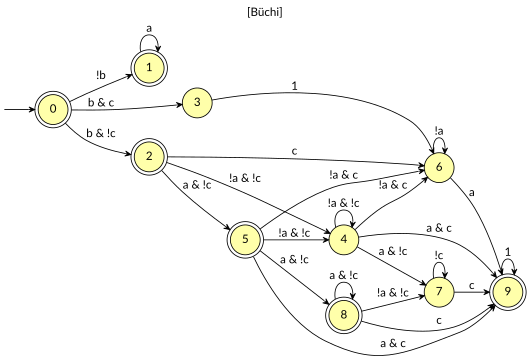

In [46]:
t5m = spot.minimize_mtdswa(t5)
print(t5.num_roots(), "roots, minimized to", t5m.num_roots(), "roots.")
display(t5m.show('0'), t5m.as_twa(True))

While this is not mentionned in Löding's paper, the ranking computed by `loding_weak_ranking` can be used to speed up Moore's minimization by interpreting it as the initial partition of the states.  Since the ranking is related both to the acceptance of the state, and to the number of alternation between accepting and rejecting SCCs that be reached from there, two states can only be merged if they have the same rank.

In [47]:
t5m = spot.minimize_mtdswa(t5, t5rank)  # <- initial partition given as second argument.
print(t5.num_roots(), "roots, minimized to", t5m.num_roots(), "roots.")
# The result is the same as above.

11 roots, minimized to 9 roots.


# Converting sinks to states or constants

Now 

In [48]:
am.sinks_as_states(); am.show('s')

In [49]:
am.sinks_as_constants(); am.show('s')

In [50]:
a1 = spot.obligation_to_mtdswa('Ga')

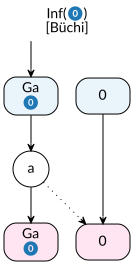

In [51]:
# This one requires changing the acceptance condition
a1.sinks_as_states(); a1

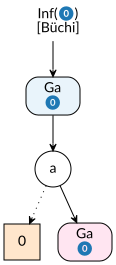

In [52]:
# Comming back to constants do the change the acceptance condition
a1.sinks_as_constants(); a1

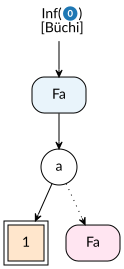

In [53]:
a2 = spot.obligation_to_mtdswa('Fa'); a2

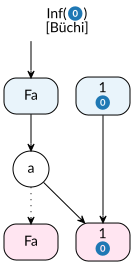

In [54]:
a2.sinks_as_states(); a2

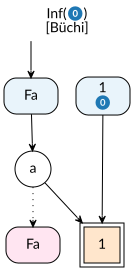

In [55]:
# The optional argument asks to uses constants, but without removing the original sink states.
a2.sinks_as_constants(True); a2

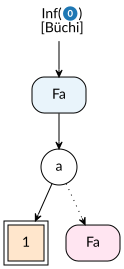

In [56]:
a2.sinks_as_constants(); a2

# Game interpretation

Work in progress.

In [57]:
am.set_controllable_variables(['s', 'p'])
am.show('s')